<a href="https://colab.research.google.com/github/harishmuh/Computer_Vision_study/blob/main/Pose_detection_with_YOLOv8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Human Pose detection with YOLOv8 model**

## **Context**

Human pose estimation is a computer vision task that involves detecting and localizing keypoints (also known as joints or landmarks) of the human body in images or videos. These keypoints typically include parts like the head, shoulders, elbows, wrists, hips, knees, and ankles. The goal is to understand the posture and movement of a person.

**Benefits of Human Pose Detection**

Human pose detection offers a wide array of applications across various domains, including:

*   **Healthcare and Fitness**: Monitoring exercises, analyzing gait for medical diagnosis, fall detection in the elderly, and rehabilitation.
*   **Sports Analysis**: Improving athlete performance by analyzing movement, form, and technique.
*   **Gaming and Augmented Reality (AR)**: Enabling natural user interfaces for games, virtual try-on experiences, and interactive AR applications.
*   **Surveillance and Security**: Anomaly detection, crowd analysis, and recognizing suspicious activities based on body posture.
*   **Robotics**: Allowing robots to understand and mimic human movements for human-robot interaction and collaborative tasks.
*   **Animation and Entertainment**: Character animation, motion capture, and creating realistic digital avatars.

**Limitations with YOLOv8 for Pose Detection**

While YOLOv8 is a powerful and efficient model for object detection and pose estimation, it does come with certain limitations, especially in complex scenarios:

*   **Occlusion**: Performance can degrade significantly when keypoints or entire body parts are heavily occluded by other objects or people.
*   **Crowded Scenes**: In very dense crowds, distinguishing individual poses and tracking keypoints accurately becomes challenging, leading to missed detections or incorrect associations.
*   **Scale Variation**: Detecting poses of very small or very large individuals in an image can be difficult due to scale differences, sometimes requiring specific training or data augmentation.
*   **Complex Poses**: Extremely unusual or highly contorted poses might not be well-represented in training data, leading to less accurate predictions.
*   **Computational Resources**: Although efficient, running YOLOv8 (especially larger models) on real-time video streams or high-resolution images still requires substantial computational resources (e.g., powerful GPUs), limiting deployment on edge devices.
*   **Generalization to New Environments/Lighting**: The model's performance can drop when applied to environments with drastically different lighting conditions, backgrounds, or viewpoints than those seen during training.
*   **Keypoint Accuracy vs. Object Detection**: While good for overall pose detection, the precision of individual keypoint localization might sometimes be lower than specialized keypoint-only models.

**Initial setup**

In [2]:
# Installing additional library
# !pip install ultralytics #Remove the ('#') to install

In [3]:
# Importing libraries
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import urllib.request
import numpy as np
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


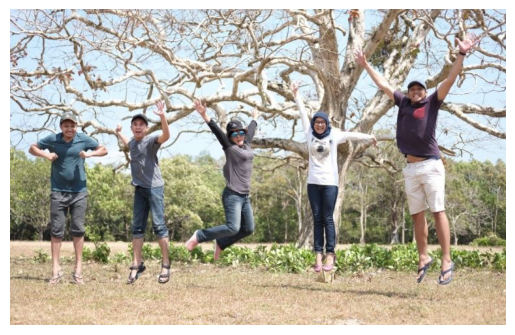

In [7]:
# Attaching the input image

# Image link
url = 'https://github.com/harishmuh/Computer_Vision_study/blob/main/data/images/people_5_jpg.JPG?raw=true'

# Download and open the image
with urllib.request.urlopen(url) as f:
    input_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img = np.array(input_img)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img, cmap='gray')
plt.show()

## **Pose detection on a static image**

In [5]:
# Preparing YOLOv8

# Downloading YOLOv8 starter files
model = YOLO('yolov8m-pose.pt')


0: 416x640 5 persons, 887.4ms
Speed: 3.8ms preprocess, 887.4ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 640)


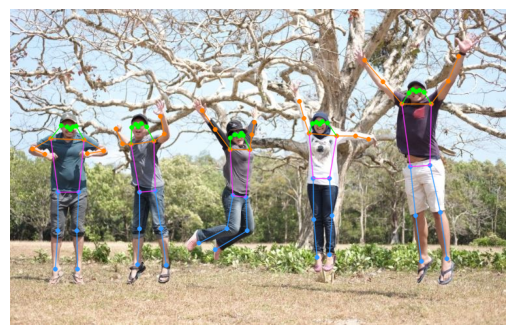

In [9]:
# Conduting pose detection (YOLOv8) in input image
prediction = model.predict(input_img, agnostic_nms=True)
result = prediction[0]

# plot pose detection result on the input image
img_detect = result.plot(boxes=False, labels=False, conf=False, kpt_radius=3)

# Displaying the detected image
plt.axis('off')
plt.imshow(img_detect)
plt.show()

We can see that poses from all 5 people on the image were detected.

## **Pose detection on Canvas**

We can also use canvas to make extracted keypoints look clearer.

In [11]:
# Preparing canvas
canvas =  np.zeros(shape = input_img.shape)

In [12]:
# Preparing YOLO model
model = YOLO('yolov8s-pose.pt')


0: 416x640 5 persons, 409.9ms
Speed: 4.0ms preprocess, 409.9ms inference, 0.9ms postprocess per image at shape (1, 3, 416, 640)


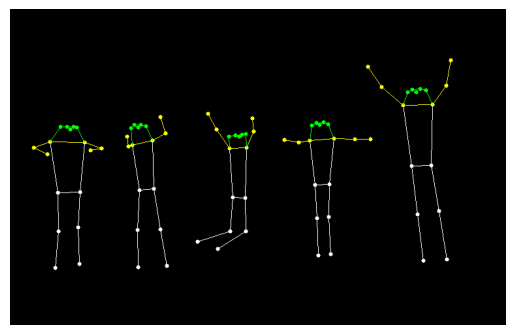

In [13]:
# Conduting pose detection  (YOLOv8) in input image
prediction = model.predict(input_img, agnostic_nms=True)
result = prediction[0]

# plot pose detection result on the input image
img_detect_canvas = result.plot(boxes=False, labels=False, conf=False, kpt_radius=3, img=canvas)

# Displaying the detected image
plt.axis('off')
plt.imshow(img_detect_canvas)
plt.show()

We can see the detected poses clearer on the black canvas

## **Conclusion**

This notebook demonstrated the basic usage of YOLOv8 for human pose detection on static images, both directly on the image and on a blank canvas for clearer keypoint visualization. YOLOv8 proves to be a versatile tool for this task, though its limitations in complex scenarios like heavy occlusion or crowded scenes should be considered. Further development could involve real-time video processing or integration with other computer vision tasks.